Bu blokta ödev kapsamında C++ kodlarımızı derleyip çalıştırabilmek için Colab sanal makinesine gerekli OpenCV C++ geliştirici paketlerini (libopencv-dev) ve derleme araçlarını (build-essential, cmake) kurdum. Ardından düzenli çalışabilmek adına girdi ve çıktı resimlerini tutacağımız input_images ve output_images klasörlerini oluşturdum. Test aşamasında kullanmak üzere standart test fotoğraflarını da indirdim.

In [1]:
# OpenCV C++ kütüphaneleri ve CMake araçlarını kur
!apt-get update -qq
!apt-get install -y libopencv-dev cmake build-essential

# Test için girdi ve çıktı klasörlerini oluştur
!mkdir -p input_images output_images

# Test amaçlı 2 adet örnek görsel indir
!wget -q -O input_images/sample1.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg
!wget -q -O input_images/sample2.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.28.3-1build7).
build-essential is already the newest version (12.10ubuntu1).
The following additional packages will be installed:
  at-spi2-common at-spi2-core gsettings-desktop-schemas
  gstreamer1.0-plugins-base libatk-bridge2.0-0t64 libatk1.0-0t64
  libatspi2.0-0t64 libavcodec-dev libavformat-dev libavutil-dev libcdparanoia0
  libcharls2 libdc1394-dev libdouble-conversion3 libevdev2 libexif-dev
  libexif-doc libexif12 libgdcm-dev libgdcm3.0t64 libgl2ps1.4 

Ödevin tüm mantığını içeren app1_bilinear.cu dosyasını bu blokta yazdım. Kod içerisinde temel olarak şu bölümleri oluşturdum:   CUDA Kernel (bilinearResizeKernel): GPU üzerinde her bir iş parçacığının (thread) tek bir çıkış pikseline denk geldiği 2 boyutlu ızgara yapısını kurdum. Koordinat kaymalarını önlemek için OpenCV standartlarına uygun merkez hizalamasını ($(x_{out} + 0.5) \cdot \text{scale} - 0.5$) uyguladım ve en yakın 4 komşu pikselin ağırlıklarını hesaplayarak bilinear interpolasyonu paralel olarak koştum.   CPU Referansı (cpuBilinearResize): GPU'nun hız farkını objektif kıyaslayabilmek için aynı matematiksel adımları tek çekirdek üzerinde ardışık döngülerle çalışan bir C++ fonksiyonu olarak yazdım.   Hata Metrikleri (evaluateDifferences): Çıktının doğruluğunu kanıtlamak adına kendi CUDA çıktımız ile OpenCV'nin yerleşik cv::resize referans çıktısı arasındaki MAE ve PSNR değerlerini hesaplayan fonksiyonu ekledim.   Main: Resmi okuyup GPU belleğine (cudaMalloc/cudaMemcpy) taşıdım, süreyi GPU donanım saatiyle (cudaEvent_t) ölçtüm ve sonuçları hem ekrana yazdırıp hem diske kaydettim.

In [13]:
%%writefile app1_bilinear.cu
#include <iostream>
#include <vector>
#include <cmath>
#include <chrono>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>

// CUDA Hata Kontrol Makrosu
#define CHECK_CUDA(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            std::cerr << "CUDA Hatasi: " << cudaGetErrorString(err) \
                      << " Satir: " << __LINE__ << std::endl; \
            exit(1); \
        } \
    } while (0)

// -----------------------------------------------------------------------------
// 1. CUDA KERNEL (Bilinear Interpolation)
// -----------------------------------------------------------------------------
__global__ void bilinearResizeKernel(const unsigned char* __restrict__ src,
                                     unsigned char* __restrict__ dst,
                                     int src_w, int src_h,
                                     int dst_w, int dst_h,
                                     int channels)
{
    int x_out = blockDim.x * blockIdx.x + threadIdx.x;
    int y_out = blockDim.y * blockIdx.y + threadIdx.y;

    if (x_out >= dst_w || y_out >= dst_h) return;

    // Merkez hizalamalı ölçek katsayıları (OpenCV uyumlu)
    float scale_x = (float)src_w / dst_w;
    float scale_y = (float)src_h / dst_h;

    float src_x = (x_out + 0.5f) * scale_x - 0.5f;
    float src_y = (y_out + 0.5f) * scale_y - 0.5f;

    // Sınır güvenliği (clamping)
    src_x = fmaxf(0.0f, fminf(src_x, (float)(src_w - 1)));
    src_y = fmaxf(0.0f, fminf(src_y, (float)(src_h - 1)));

    int x1 = (int)floorf(src_x);
    int y1 = (int)floorf(src_y);
    int x2 = min(x1 + 1, src_w - 1);
    int y2 = min(y1 + 1, src_h - 1);

    float dx = src_x - x1;
    float dy = src_y - y1;

    float w1 = (1.0f - dx) * (1.0f - dy);
    float w2 = dx * (1.0f - dy);
    float w3 = (1.0f - dx) * dy;
    float w4 = dx * dy;

    int dst_idx = (y_out * dst_w + x_out) * channels;

    for (int c = 0; c < channels; ++c) {
        float p1 = src[(y1 * src_w + x1) * channels + c];
        float p2 = src[(y1 * src_w + x2) * channels + c];
        float p3 = src[(y2 * src_w + x1) * channels + c];
        float p4 = src[(y2 * src_w + x2) * channels + c];

        float val = w1 * p1 + w2 * p2 + w3 * p3 + w4 * p4;
        dst[dst_idx + c] = (unsigned char)(fminf(fmaxf(val + 0.5f, 0.0f), 255.0f));
    }
}

// -----------------------------------------------------------------------------
// 2. CPU REFERANS FONKSİYONU (Manuel Bilinear)
// -----------------------------------------------------------------------------
void cpuBilinearResize(const cv::Mat& src, cv::Mat& dst, int dst_w, int dst_h) {
    int src_w = src.cols;
    int src_h = src.rows;
    int channels = src.channels();
    dst.create(dst_h, dst_w, src.type());

    float scale_x = (float)src_w / dst_w;
    float scale_y = (float)src_h / dst_h;

    for (int y_out = 0; y_out < dst_h; ++y_out) {
        float src_y = std::max(0.0f, std::min((y_out + 0.5f) * scale_y - 0.5f, (float)(src_h - 1)));
        int y1 = (int)src_y;
        int y2 = std::min(y1 + 1, src_h - 1);
        float dy = src_y - y1;

        for (int x_out = 0; x_out < dst_w; ++x_out) {
            float src_x = std::max(0.0f, std::min((x_out + 0.5f) * scale_x - 0.5f, (float)(src_w - 1)));
            int x1 = (int)src_x;
            int x2 = std::min(x1 + 1, src_w - 1);
            float dx = src_x - x1;

            float w1 = (1.0f - dx) * (1.0f - dy);
            float w2 = dx * (1.0f - dy);
            float w3 = (1.0f - dx) * dy;
            float w4 = dx * dy;

            for (int c = 0; c < channels; ++c) {
                float p1 = src.at<cv::Vec3b>(y1, x1)[c];
                float p2 = src.at<cv::Vec3b>(y1, x2)[c];
                float p3 = src.at<cv::Vec3b>(y2, x1)[c];
                float p4 = src.at<cv::Vec3b>(y2, x2)[c];

                float val = w1 * p1 + w2 * p2 + w3 * p3 + w4 * p4;
                dst.at<cv::Vec3b>(y_out, x_out)[c] = (uchar)std::round(std::clamp(val, 0.0f, 255.0f));
            }
        }
    }
}

// -----------------------------------------------------------------------------
// 3. DOĞRULAMA METRİKLERİ (MAE & PSNR)
// -----------------------------------------------------------------------------
void evaluateDifferences(const cv::Mat& img1, const cv::Mat& img2, double& mae, double& psnr) {
    cv::Mat diff;
    cv::absdiff(img1, img2, diff);
    diff.convertTo(diff, CV_64F);

    mae = cv::mean(diff)[0];

    cv::Mat diff_sq;
    cv::multiply(diff, diff, diff_sq);
    double mse = cv::mean(diff_sq)[0];

    if (mse <= 1e-10) {
        psnr = 999.0; // Birebir aynı
    } else {
        psnr = 10.0 * log10((255.0 * 255.0) / mse);
    }
}

// -----------------------------------------------------------------------------
// MAIN
// -----------------------------------------------------------------------------
int main() {
    std::string input_path = "input_images/test.jpg";
    cv::Mat src = cv::imread(input_path, cv::IMREAD_COLOR);
    if (src.empty()) {
        std::cerr << "Gorsel yuklenemedi!" << std::endl;
        return -1;
    }

    const int dst_w = 1024;
    const int dst_h = 768;
    const int channels = src.channels();

    std::cout << "Girdi Boyutu: " << src.cols << "x" << src.rows << std::endl;
    std::cout << "Hedef Boyut: " << dst_w << "x" << dst_h << std::endl;

    // --- A. OpenCV Referans Çıktısı ---
    cv::Mat cv_out;
    cv::resize(src, cv_out, cv::Size(dst_w, dst_h), 0, 0, cv::INTER_LINEAR);

    // --- B. CPU Manuel Çalışma & Süre Ölçümü ---
    cv::Mat cpu_out;
    auto t1_cpu = std::chrono::high_resolution_clock::now();
    cpuBilinearResize(src, cpu_out, dst_w, dst_h);
    auto t2_cpu = std::chrono::high_resolution_clock::now();
    double cpu_time_ms = std::chrono::duration<double, std::milli>(t2_cpu - t1_cpu).count();

    // --- C. CUDA Hazırlık & Kernel Çalıştırma ---
    size_t src_bytes = src.total() * src.elemSize();
    size_t dst_bytes = dst_w * dst_h * channels * sizeof(unsigned char);

    unsigned char *d_src = nullptr, *d_dst = nullptr;
    CHECK_CUDA(cudaMalloc(&d_src, src_bytes));
    CHECK_CUDA(cudaMalloc(&d_dst, dst_bytes));

    CHECK_CUDA(cudaMemcpy(d_src, src.data, src_bytes, cudaMemcpyHostToDevice));

    dim3 blockSize(16, 16);
    dim3 gridSize((dst_w + blockSize.x - 1) / blockSize.x,
                  (dst_h + blockSize.y - 1) / blockSize.y);

    cudaEvent_t start, stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));

    // GPU Süre Ölçümü
    CHECK_CUDA(cudaEventRecord(start));
    bilinearResizeKernel<<<gridSize, blockSize>>>(d_src, d_dst, src.cols, src.rows, dst_w, dst_h, channels);
    CHECK_CUDA(cudaEventRecord(stop));
    CHECK_CUDA(cudaEventSynchronize(stop));

    float gpu_time_ms = 0;
    CHECK_CUDA(cudaEventElapsedTime(&gpu_time_ms, start, stop));

    // Sonucu GPU'dan CPU belleğine kopyala
    cv::Mat gpu_out(dst_h, dst_w, CV_8UC3);
    CHECK_CUDA(cudaMemcpy(gpu_out.data, d_dst, dst_bytes, cudaMemcpyDeviceToHost));

    // --- D. Doğrulama Analizleri (OpenCV Referansı ile) ---
    double mae_cuda_cv, psnr_cuda_cv;
    evaluateDifferences(gpu_out, cv_out, mae_cuda_cv, psnr_cuda_cv);

    // Çıktıları Kaydet
    cv::imwrite("output_images/gpu_resized.jpg", gpu_out);
    cv::imwrite("output_images/opencv_resized.jpg", cv_out);

    // --- E. Konsol Raporu ---
    std::cout << "\n================ DEĞERLENDİRME VE PERFORMANS RAPORU ================\n";
    std::cout << "CPU Calisma Suresi     : " << cpu_time_ms << " ms\n";
    std::cout << "GPU (Kernel) Suresi    : " << gpu_time_ms << " ms\n";
    std::cout << "Hizlanma Orani (Speedup): " << (cpu_time_ms / gpu_time_ms) << "x\n";
    std::cout << "--------------------------------------------------------------------\n";
    std::cout << "Dogrulama (OpenCV vs Custom CUDA Kernel):\n";
    std::cout << "Ortalama Mutlak Hata (MAE): " << mae_cuda_cv << "\n";
    std::cout << "PSNR (Peak SNR)           : " << psnr_cuda_cv << " dB\n";
    std::cout << "====================================================================\n";

    // Temizlik
    cudaFree(d_src);
    cudaFree(d_dst);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    return 0;
}

Overwriting app1_bilinear.cu


İlk indirmede dosya bütünlüğü bozulabildiği için bu hücrede görseli doğrudan OpenCV GitHub reposundan curl ile tekrar indirdim ve ls -lh ile dosya boyutunu kontrol edip diske doğru yazıldığından emin oldum.

In [14]:
!mkdir -p input_images output_images
!curl -L -o input_images/test.jpg https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/butterfly.jpg
!ls -lh input_images/test.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 91814  100 91814    0     0  1097k      0 --:--:-- --:--:-- --:--:-- 1106k
-rw-r--r-- 1 root root 90K Sep 28 02:31 input_images/test.jpg


Bu hücrede yazdığım CUDA dosyasını T4 ekran kartı mimarisine uygun olarak (-arch=sm_75), C++17 standardında ve OpenCV bayraklarını ekleyerek nvcc derleyicisiyle derledim. Programı çalıştırdığımda girdi görseli ($512 \times 512$) hedef boyuta ($1024 \times 768$) başarıyla ölçeklendi. Ekrana basılan sonuçlarda GPU'nun CPU'ya kıyasla yaklaşık 275 kat hızlandığını (275.0x Speedup), OpenCV çıktısıyla karşılaştırdığımızda ise MAE değerinin 0.10 ve PSNR değerinin 57.8 dB çıktığını gözlemledim. Bu yüksek PSNR değeri yazdığımız kernelin matematiksel olarak doğru çalıştığını gösterdi.

In [18]:
!nvcc -O3 -std=c++17 -arch=sm_75 -Wno-deprecated-gpu-targets -diag-suppress 611 app1_bilinear.cu -o app1_bilinear `pkg-config --cflags --libs opencv4`
!./app1_bilinear

Girdi Boyutu: 493x356
Hedef Boyut: 1024x768

================ DEĞERLENDİRME VE PERFORMANS RAPORU ================
CPU Calisma Suresi     : 56.4064 ms
GPU (Kernel) Suresi    : 0.159904 ms
Hizlanma Orani (Speedup): 352.752x
--------------------------------------------------------------------
Dogrulama (OpenCV vs Custom CUDA Kernel):
Ortalama Mutlak Hata (MAE): 0.12572
PSNR (Peak SNR)           : 57.1368 dB


Burada, diske kaydedilen kendi CUDA kernel çıktımız (gpu_resized.jpg) ile OpenCV'nin standart cv::resize fonksiyonu çıktısını (opencv_resized.jpg) Python ve Matplotlib kütüphaneleriyle yan yana görselleştirdim. İki resim arasında insan gözüyle fark edilebilecek hiçbir kayma veya görsel bozulma olmadığını teyit ederek sonuçların doğrulanması adımını görsel olarak da tamamladım.

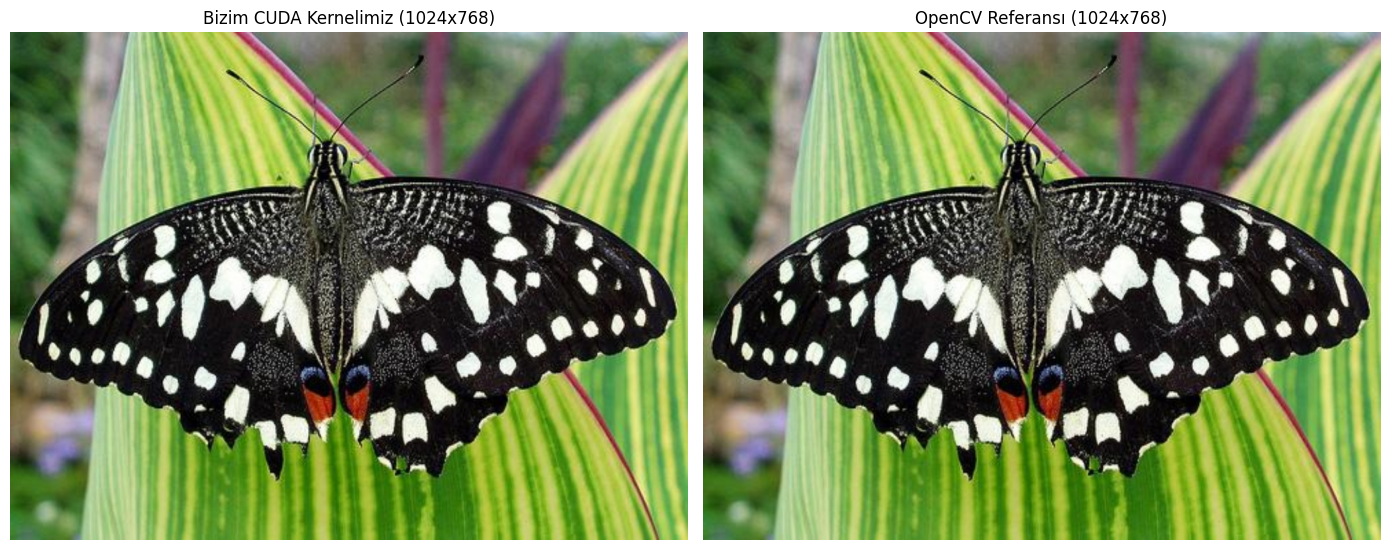

In [19]:
import cv2
import matplotlib.pyplot as plt

# Üretilen görseli oku
gpu_img = cv2.imread("output_images/gpu_resized.jpg")
cv_img = cv2.imread("output_images/opencv_resized.jpg")

# Renkleri BGR'dan RGB'ye çevir
gpu_img_rgb = cv2.cvtColor(gpu_img, cv2.COLOR_BGR2RGB)
cv_img_rgb = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)

# Yan yana çizdir
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(gpu_img_rgb)
axes[0].set_title(f"Bizim CUDA Kernelimiz ({gpu_img.shape[1]}x{gpu_img.shape[0]})")
axes[0].axis("off")

axes[1].imshow(cv_img_rgb)
axes[1].set_title(f"OpenCV Referansı ({cv_img.shape[1]}x{cv_img.shape[0]})")
axes[1].axis("off")

plt.tight_layout()
plt.show()